### Importing dependencies for our code requirment:


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [29]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score, accuracy_score

In [11]:
df = pd.read_csv('DataSets/Concrete.csv')

In [12]:
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [13]:
# renaming of csMPa to strenght
df = df.rename(columns = {'csMPa' : 'strength'})

In [14]:
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
strength            0
dtype: int64

In [15]:
df.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [16]:
X = df.drop('strength', axis = 1)
y = df['strength']

In [19]:
X.shape

(1030, 8)

In [20]:
y.shape

(1030,)

In [24]:
# train test split
x_train, x_test , y_train, y_test = train_test_split(X, y , test_size = 0.25, random_state = 42)

In [32]:
# applying linear regression without any transformation to check accuracy of our model
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print(r2_score(y_test, y_pred))


0.6249829353885575


In [36]:
# Cross checking with cross val score
lr = LinearRegression()
print(f"{np.round(np.mean(cross_val_score(lr,X,y,scoring='r2')),2)}")

0.46


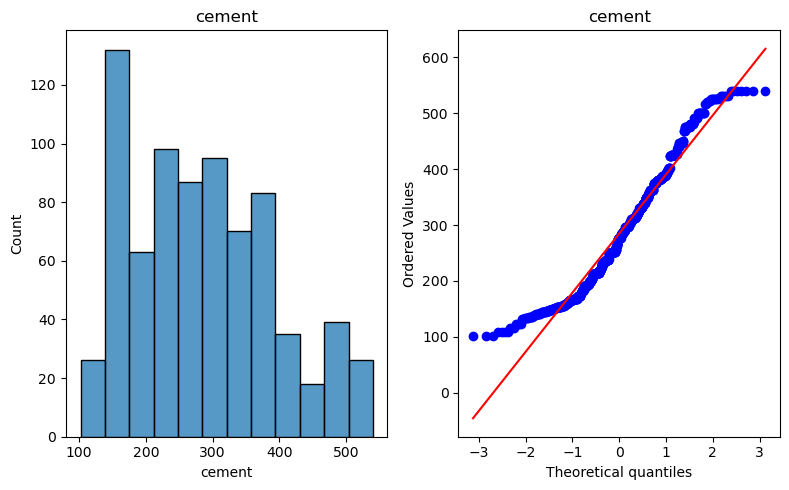

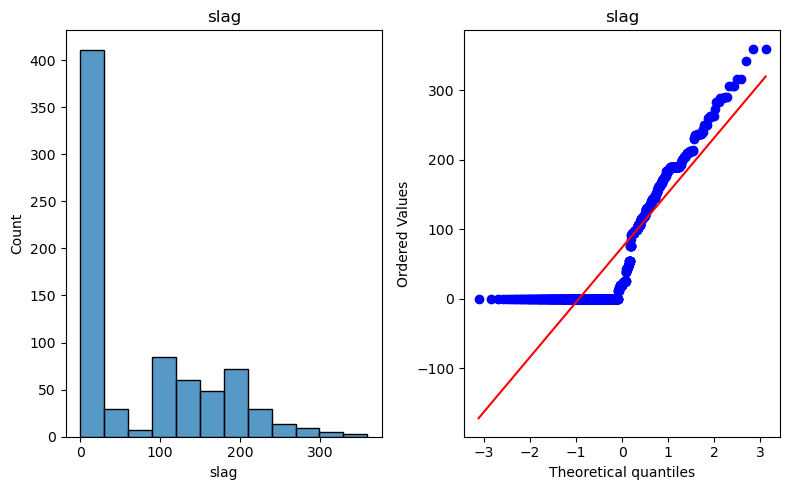

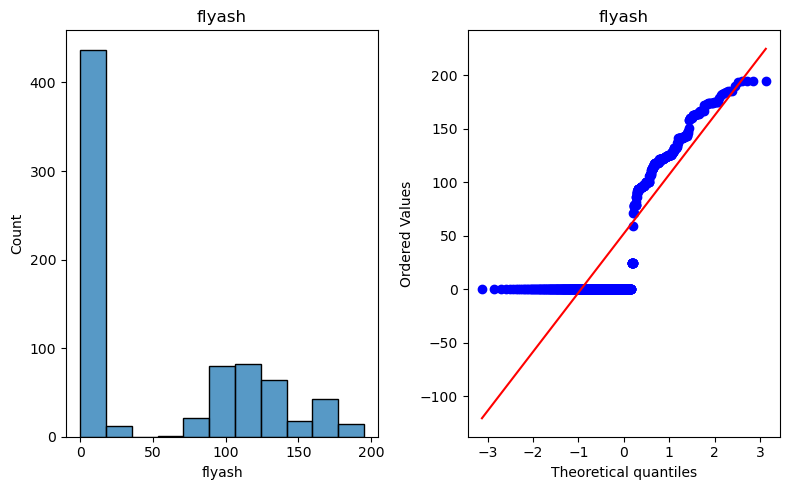

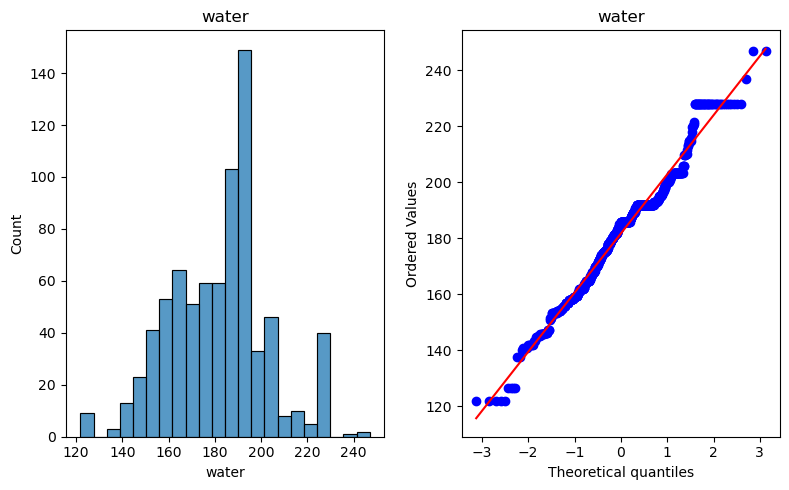

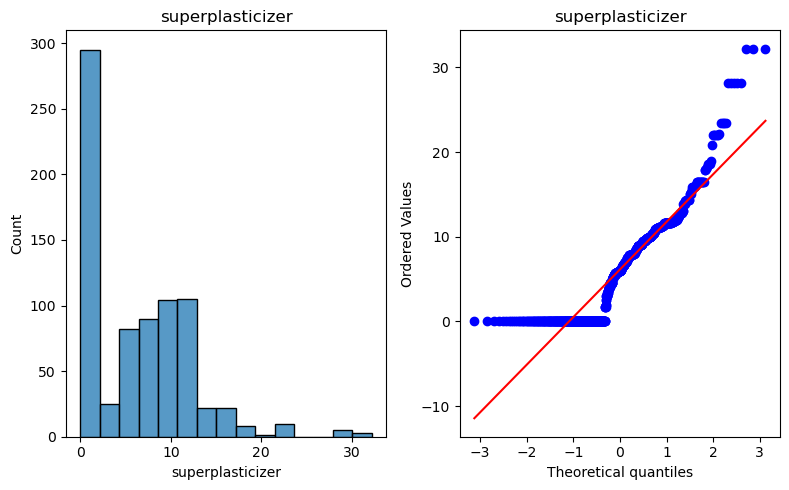

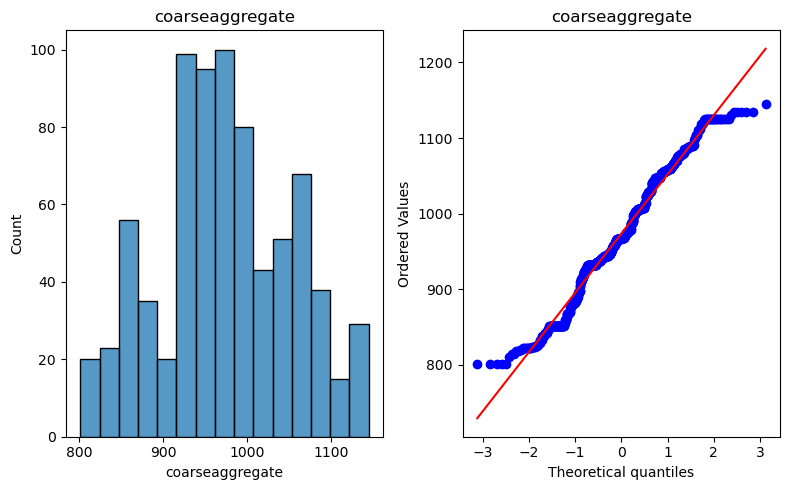

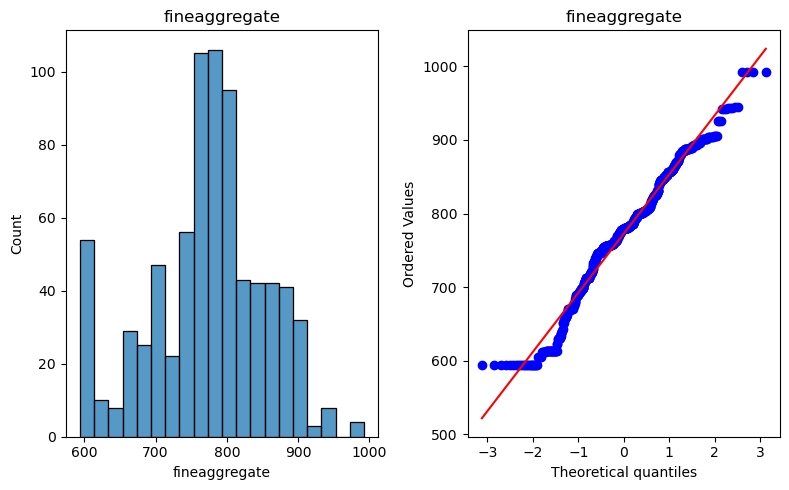

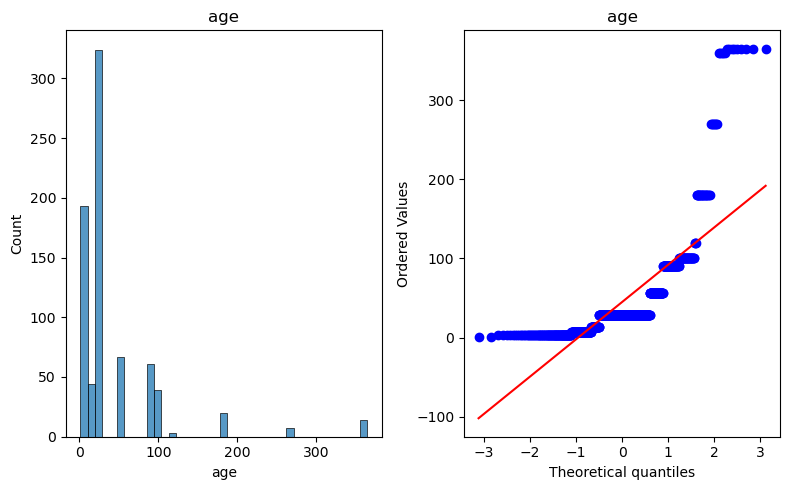

In [39]:
# ploting the displot without any transformation

for col in x_train.columns:
    plt.figure(figsize = (8,5))
    plt.subplot(1,2,1)
    sns.histplot(x_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train[col], dist = 'norm', plot = plt)
    plt.title(col)

    plt.tight_layout()
    plt.show()


In [40]:
# applying yeo-johnson transformation becuase it's best used in any numeric data like it can handle neg, positive or zeros

pt = PowerTransformer()

x_train_transformed = pt.fit_transform(x_train)
x_test_transformed = pt.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed, y_train)

y_pred = lr.predict(x_test_transformed)
print('Accuracy of our model: ', r2_score(y_test, y_pred))

Accuracy of our model:  0.8075413175568094


In [43]:
# to show our each feature after transforming

pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt.lambdas_})

,cols,Yeo_Johnson_lambdas
0,cement,0.191971
1,slag,0.000482
2,flyash,-0.178001
3,water,0.850289
4,superplasticizer,0.231695
5,coarseaggregate,1.126614
6,fineaggregate,1.860416
7,age,0.019683


In [49]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
print(np.round(np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2')),2))

0.68


In [52]:
x_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)

In [53]:
x_train_transformed

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
0,-1.182540,-1.042678,1.236481,-0.237458,0.109723,1.079957,0.044901,0.100410
1,-0.574739,0.858362,0.675777,0.007425,0.437582,1.175142,0.113076,-0.495785
2,0.567381,-1.042678,-0.873347,0.489439,-1.209775,-0.545105,0.858611,-1.057114
3,1.652443,0.320111,1.163235,1.322714,0.002934,-1.165384,-0.930129,0.100410
4,-0.911244,0.954840,-0.873347,0.195086,-1.209775,1.399282,-0.152251,0.100410
...,...,...,...,...,...,...,...,...
767,0.166773,1.153087,-0.873347,-1.759924,0.929482,0.387949,0.345825,-1.668074
768,-0.215517,-1.042678,1.167710,-1.828028,1.001581,1.443133,0.309719,-0.495785
769,-0.858822,-1.042678,1.167920,-0.706684,0.804160,1.342560,0.283996,1.250293
770,1.556647,0.936913,-0.873347,-0.020777,0.699689,-1.540225,0.062537,0.100410


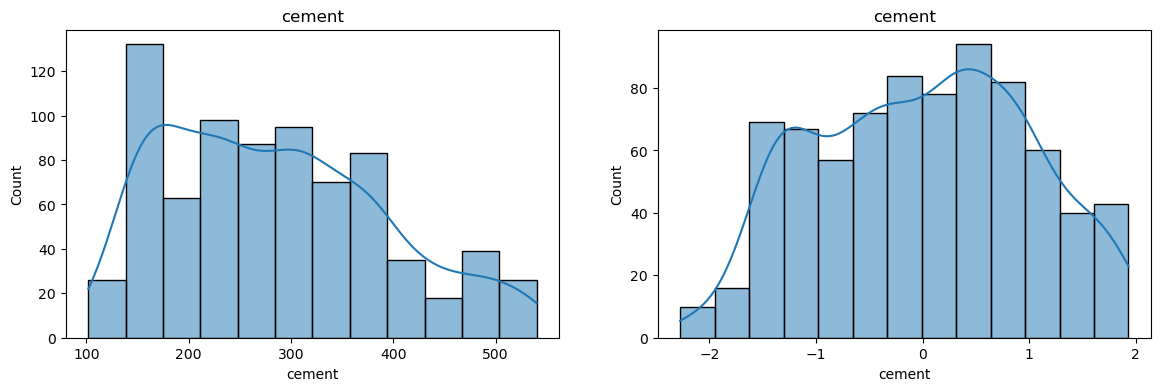

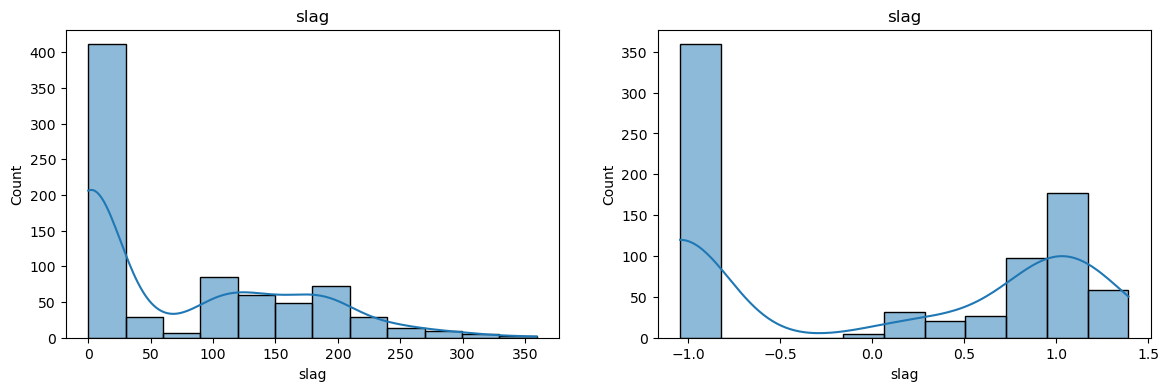

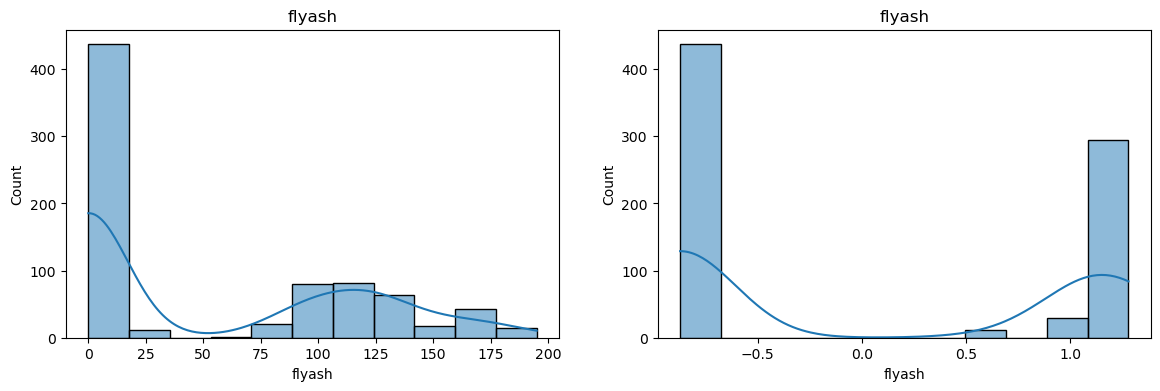

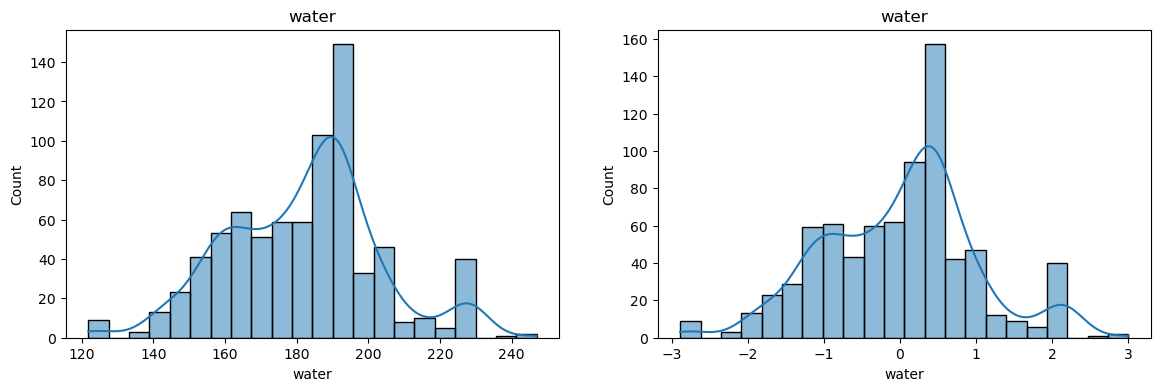

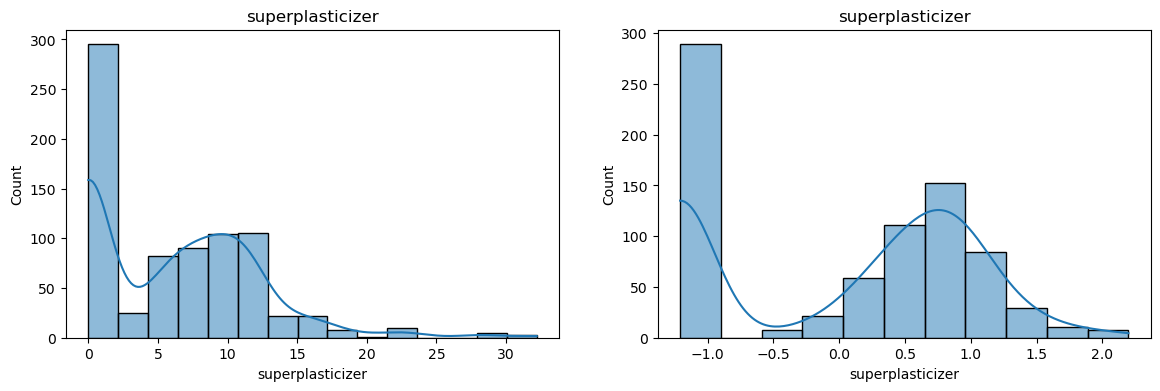

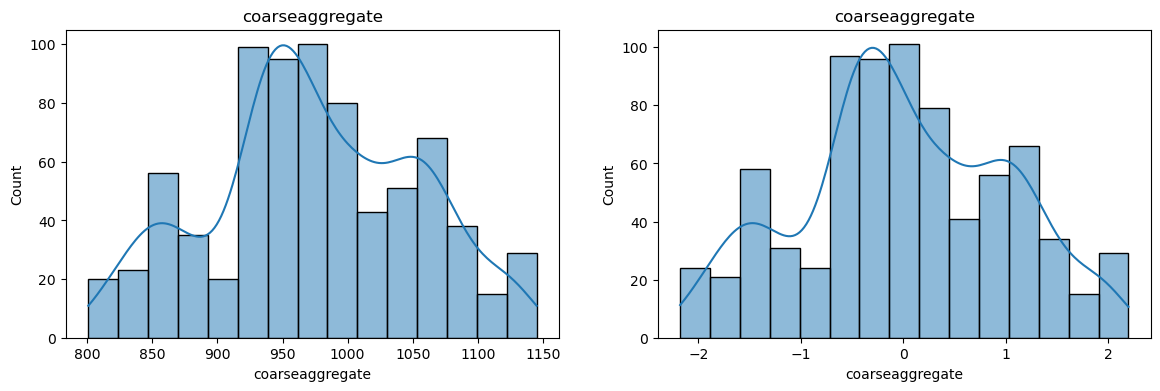

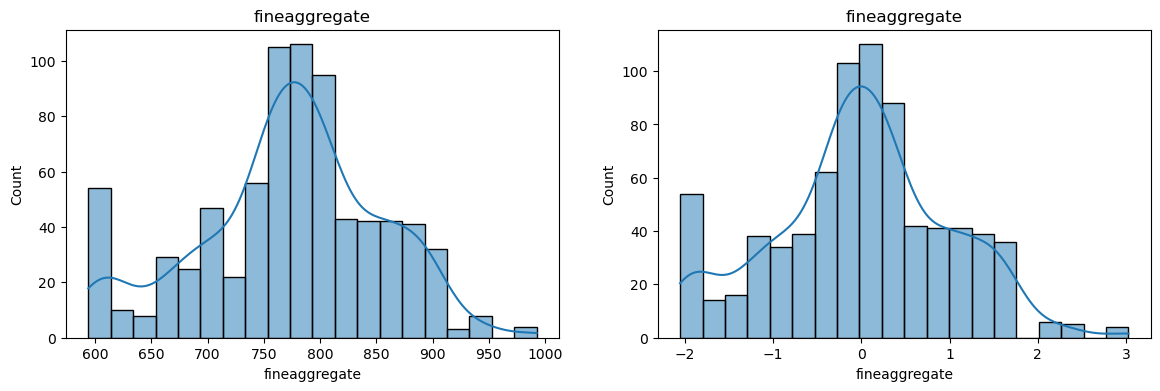

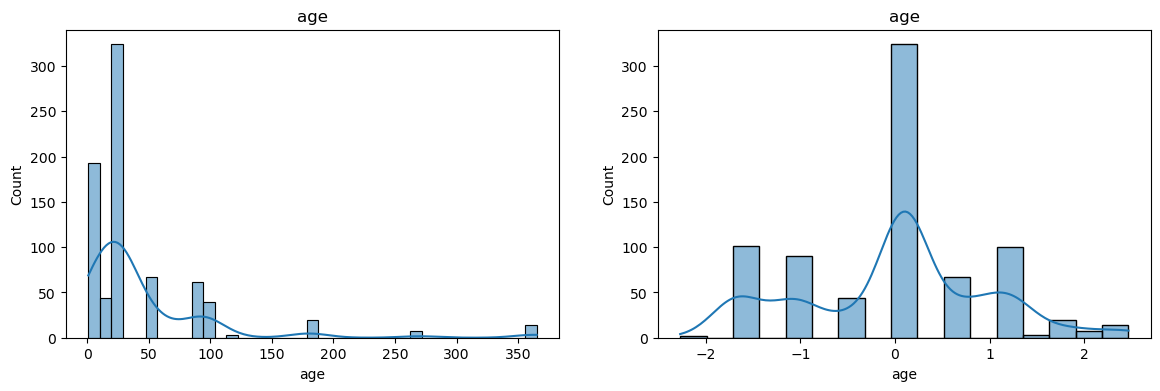

In [56]:
# Before and after comparision for Yeo-Johnson

for col in x_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col], kde = True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed[col], kde = True)
    plt.title(col)

    plt.show()

In [57]:
# Side by side Lambdas
pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,cement,0.169544,0.169544
1,slag,0.016633,0.016633
2,flyash,-0.136480,-0.136480
3,water,0.808438,0.808438
4,superplasticizer,0.264160,0.264160
5,coarseaggregate,1.129395,1.129395
6,fineaggregate,1.830763,1.830763
7,age,0.001771,0.001771
